In [27]:
# Imports
import sys
sys.path.insert(1, '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/')
import importlib
import numpy as np
import awkward as ak
import pandas as pd
# from particle import Particle
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
#from mpl_toolkits.mplot3d import Axes3D
from python.analysis import BeamParticleSelection, Master, SelectionTools, PFOSelection
from python.analysis import SelectionEvaluation as seval
from python.analysis import Tags, Plots
from python.pdhd_MC import beam_selection
importlib.reload(Master)
importlib.reload(BeamParticleSelection)
importlib.reload(SelectionTools)
importlib.reload(Tags)
importlib.reload(beam_selection)

2026-06-30 15:57:11.763298: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<module 'python.pdhd_MC.beam_selection' from '/users/gj23442/analysis/pion-argon-xs-analysis/analysis/python/pdhd_MC/beam_selection.py'>

In [58]:
## Original PDSP Analyser config

filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v1__gen_g4_IonScintPDExt_PDInt.root"
events_v1 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [59]:
## Fixed calo modules but Vplane collector config on

filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v2__gen_g4_IonScintPDExt_PDInt.root"
events_v2 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [60]:
## Fixed calo modules but Vplane collector config off

filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v3__gen_g4_IonScintPDExt_PDInt.root"
events_v3 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [61]:
## Fixed calo modules but Vplane collector config on and the config moved to fcl

filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v4__gen_g4_IonScintPDExt_PDInt.root"
events_v4 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [62]:
## Attempt to fix michel score

filename = "/storage/2/gj23442/PDSPAnalyser_tests/ana_pdhd_prod_beam_test_v6__gen_g4_IonScintPDExt_PDInt.root"
events_v6 = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [63]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_v1, return_property=True)

mask = true_beam_mask[0]
bi_evts = events_v1.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v1_evts = track_evts.Filter([mask], [mask], returnCopy=True)

In [64]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_v2, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_v2.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v2_evts = track_evts.Filter([mask], [mask], returnCopy=True)

In [65]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_v3, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_v3.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v3_evts = track_evts.Filter([mask], [mask], returnCopy=True)

In [66]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_v4, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_v4.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v4_evts = track_evts.Filter([mask], [mask], returnCopy=True)

In [67]:
true_beam_mask = beam_selection.BeamTriggerSelection(events_v6, return_property=True)
mask = true_beam_mask[0]
bi_evts = events_v6.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_v6_evts = track_evts.Filter([mask], [mask], returnCopy=True)

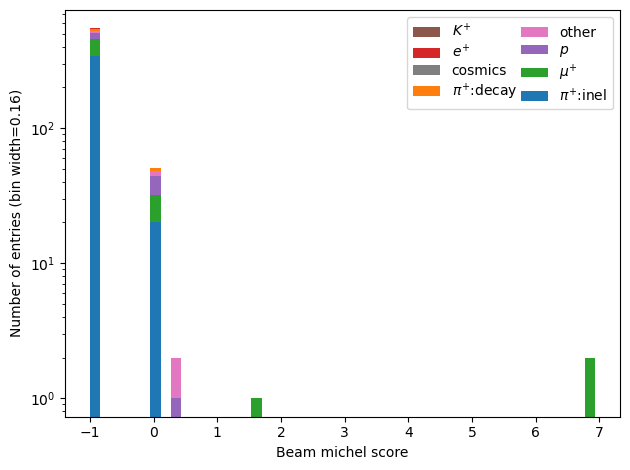

In [68]:
tags = Tags.GenerateBeamCandidateTags(selected_v4_evts)
Plots.PlotTagged(selected_v4_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

In [70]:
ak.sum(selected_v4_evts.recoParticles.beam_michelScore == -1), ak.sum(selected_v6_evts.recoParticles.beam_michelScore == -1)

(545, 545)

In [71]:
len(selected_v4_evts.recoParticles.beam_michelScore), len(selected_v6_evts.recoParticles.beam_michelScore)

(601, 601)

In [91]:
tags = Tags.GenerateBeamCandidateTags(selected_v1_evts)
print(tags.name.values)
x, y = np.unique(selected_v1_evts.recoParticles.beam_michelScore[tags.mask.values[2]], return_counts=True)
np.array(x, dtype=float), np.array(y)

['$\\pi^{+}$:inel', '$\\pi^{+}$:decay', '$\\mu^{+}$', '$e^{+}$', '$p$', '$K^{+}$', 'other', 'cosmics']


(array([-1.00000000e+00,  0.00000000e+00,  5.63984290e-05,  8.56947815e-03,
         1.27275048e-02,  1.60194133e+00,  6.83790917e+00,  6.92595607e+00]),
 array([112,   9,   1,   1,   1,   1,   1,   1]))

In [92]:
tags = Tags.GenerateBeamCandidateTags(selected_v4_evts)
print(tags.name.values)
x, y = np.unique(selected_v4_evts.recoParticles.beam_michelScore[tags.mask.values[2]], return_counts=True)
np.array(x, dtype=float), np.array(y)

['$\\pi^{+}$:inel', '$\\pi^{+}$:decay', '$\\mu^{+}$', '$e^{+}$', '$p$', '$K^{+}$', 'other', 'cosmics']


(array([-1.00000000e+00,  0.00000000e+00,  5.63984290e-05,  8.56947815e-03,
         1.27275048e-02,  1.60194133e+00,  6.83790917e+00,  6.92595607e+00]),
 array([112,   9,   1,   1,   1,   1,   1,   1]))

In [93]:
tags = Tags.GenerateBeamCandidateTags(selected_v6_evts)
print(tags.name.values)
x, y = np.unique(selected_v6_evts.recoParticles.beam_michelScore[tags.mask.values[2]], return_counts=True)
np.array(x, dtype=float), np.array(y)

['$\\pi^{+}$:inel', '$\\pi^{+}$:decay', '$\\mu^{+}$', '$e^{+}$', '$p$', '$K^{+}$', 'other', 'cosmics']


(array([-1.00000000e+00,  0.00000000e+00,  5.63984290e-05,  6.61170579e-05,
         5.56112480e-02,  1.60194133e+00,  6.83790917e+00,  6.92595607e+00]),
 array([112,   9,   1,   1,   1,   1,   1,   1]))

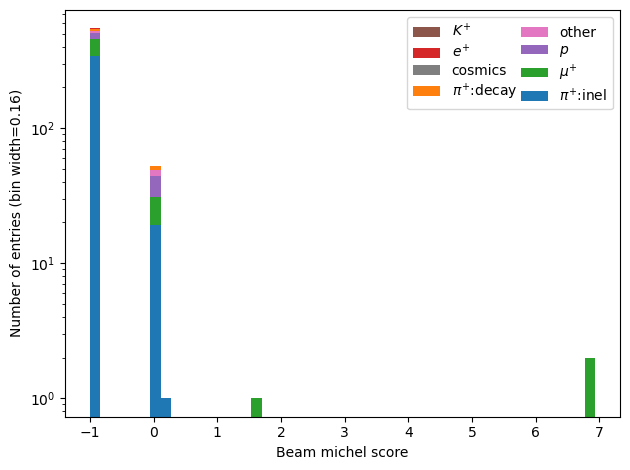

In [69]:
tags = Tags.GenerateBeamCandidateTags(selected_v6_evts)
Plots.PlotTagged(selected_v6_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")

In [18]:
print(ak.sum(ak.num(selected_v1_evts.recoParticles.beam_dEdX_noSCE)==0))
print(ak.sum(ak.num(selected_v2_evts.recoParticles.beam_dEdX_noSCE)==0))
print(ak.sum(ak.num(selected_v3_evts.recoParticles.beam_dEdX_noSCE)==0))

44
44
273


44 601


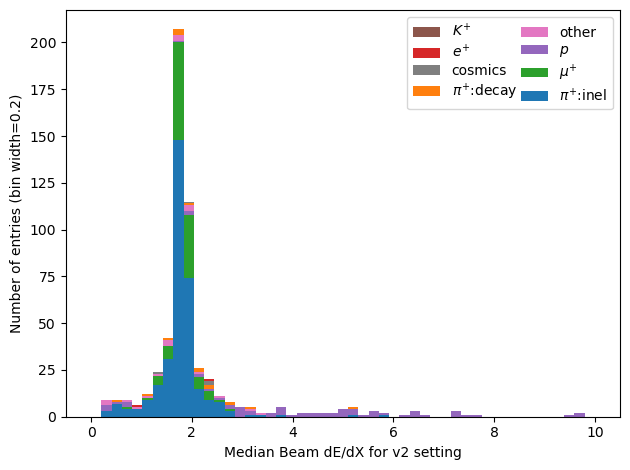

In [12]:
from python.analysis.PFOSelection import Median

median = Median(selected_v2_evts.recoParticles.beam_dEdX_noSCE)
print(ak.sum(median==-999), len(median))
tags = Tags.GenerateBeamCandidateTags(selected_v2_evts)
Plots.PlotTagged(median, tags, bins=np.linspace(0, 10, 50), y_scale="linear", x_label="Median Beam dE/dX for v2 setting")

In [26]:
filename = "/storage/2/gj23442/pdhd_prod_mc_beam__gen_g4_IonScintPDExt_PDInt_1GeV_v10_10_04d01_nosce.root"
#filename = "/storage/2/gj23442/pdhd_prod_beam__gen_g4_IonScintPDExt_PDInt_266463_7_1_20251211T023321Z_detsim_reco1_pdhd_ntuple.root"
events = Master.Data(filename, nTuple_type="PDSPAnalyser_SCEOff", target_momentum=1)

In [27]:
true_beam_mask = beam_selection.BeamTriggerSelection(events, return_property=True)

mask = true_beam_mask[0]
bi_evts = events.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamValidSelection(bi_evts)
bv_evts = bi_evts.Filter([mask], [mask], returnCopy=True)

mask = beam_selection.BeamTrackSelection(bv_evts)
track_evts = bv_evts.Filter([mask], [mask], returnCopy=True)

_, mask = beam_selection.BeamQualitySelection(track_evts)
selected_evts = track_evts.Filter([mask], [mask], returnCopy=True)

4796 10748


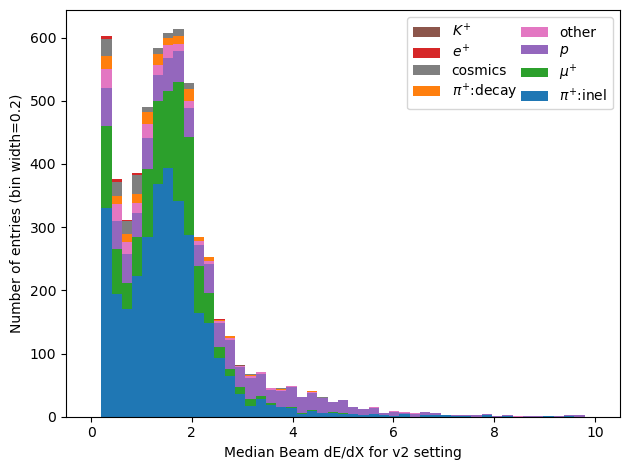

In [28]:
from python.analysis.PFOSelection import Median

median = Median(selected_evts.recoParticles.beam_dEdX_noSCE)
print(ak.sum(median==-999), len(median))
tags = Tags.GenerateBeamCandidateTags(selected_evts)
Plots.PlotTagged(median, tags, bins=np.linspace(0, 10, 50), y_scale="linear", x_label="Median Beam dE/dX for v2 setting")

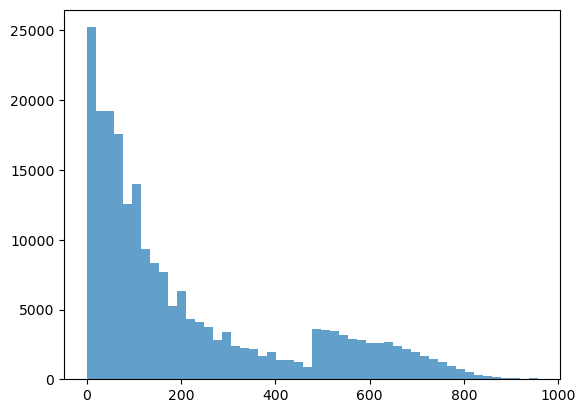

In [29]:
plt.hist(ak.flatten(selected_evts.recoParticles.beam_caloWire_noSCE), bins=50, alpha=0.7, label="v4")
plt.show()

In [30]:
beam_dEdX = selected_evts.recoParticles.beam_dEdX
n_hits = ak.num(beam_dEdX)
ak.sum(n_hits==0), len(n_hits)

(4796, 10748)

In [16]:
beam_dEdX = selected_v1_evts.recoParticles.beam_dEdX
n_hits = ak.num(beam_dEdX)
ak.sum(n_hits==0), len(n_hits)

(44, 601)

In [17]:
beam_dEdX = selected_v4_evts.recoParticles.beam_dEdX
n_hits = ak.num(beam_dEdX)
ak.sum(n_hits==0), len(n_hits)

(44, 601)

In [19]:
beam_dEdX = selected_v3_evts.recoParticles.beam_dEdX
n_hits = ak.num(beam_dEdX)
ak.sum(n_hits==0), len(n_hits)

(273, 601)

545 601


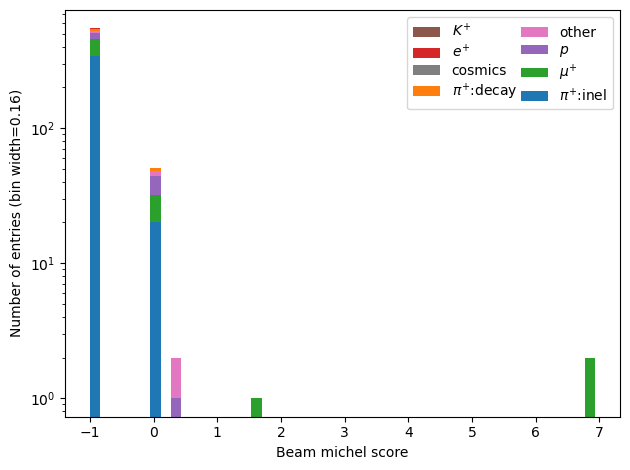

In [22]:
tags = Tags.GenerateBeamCandidateTags(selected_v1_evts)
Plots.PlotTagged(selected_v1_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")
print(ak.sum(selected_v1_evts.recoParticles.beam_michelScore==-1), len(selected_v1_evts.recoParticles.beam_michelScore))

545 601


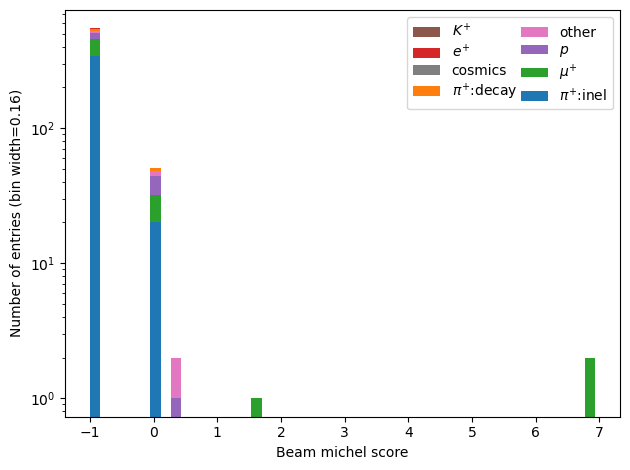

In [23]:
tags = Tags.GenerateBeamCandidateTags(selected_v2_evts)
Plots.PlotTagged(selected_v2_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")
print(ak.sum(selected_v2_evts.recoParticles.beam_michelScore==-1), len(selected_v2_evts.recoParticles.beam_michelScore))

545 601


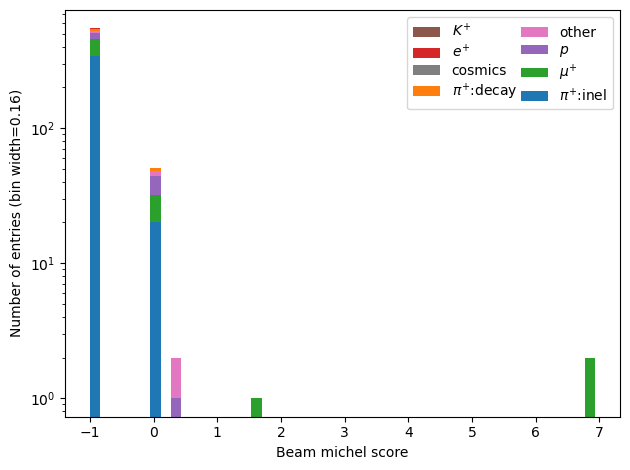

In [24]:
tags = Tags.GenerateBeamCandidateTags(selected_v3_evts)
Plots.PlotTagged(selected_v3_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")
print(ak.sum(selected_v3_evts.recoParticles.beam_michelScore==-1), len(selected_v3_evts.recoParticles.beam_michelScore))

545 601


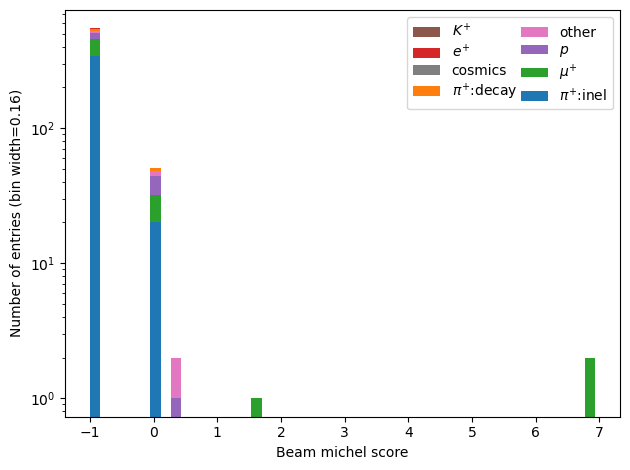

In [25]:
tags = Tags.GenerateBeamCandidateTags(selected_v4_evts)
Plots.PlotTagged(selected_v4_evts.recoParticles.beam_michelScore, tags, bins=50, y_scale='log', x_label="Beam michel score")
print(ak.sum(selected_v4_evts.recoParticles.beam_michelScore==-1), len(selected_v4_evts.recoParticles.beam_michelScore))

In [17]:
from python.analysis.SelectionTools import *

def ValidRecoEnergyCut(events : Master.Data) -> ak.Array:
    return events.recoParticles.shower_energy != -999


def ValidRecoPositionCut(events : Master.Data) -> ak.Array:
    return np.logical_and(
        np.logical_and(
            events.recoParticles.shower_start_pos.x != -999,
            events.recoParticles.shower_start_pos.y != -999
        ),
        events.recoParticles.shower_start_pos.z != 999
    )


def ValidRecoMomentumCut(events : Master.Data) -> ak.Array:
    return np.logical_and(
        np.logical_and(
            events.recoParticles.shower_momentum.x != -999,
            events.recoParticles.shower_momentum.y != -999
        ),
        events.recoParticles.shower_momentum.z != -999
    )

def GoodShowerSelection(events : Master.Data, return_table = False):
    selections = [
        ValidRecoPositionCut,
        ValidRecoMomentumCut,
        ValidRecoEnergyCut,
    ]
    return CombineSelections(events, selections, 1, return_table = return_table)

def HasFinalStatePFOsCut(events: Data, return_property : bool = False) -> ak.Array:
    """ Selects events which have final state PFOs that are well reconstructed.

    Args:
        events (Data): events to look at
        return_property (bool, optional): returns quantity cut on. Defaults to False.

    Returns:
        ak.Array: _description_
    """
    pfo_mask = GoodShowerSelection(events) # create this mask internally so that the PFO and event selections remain separate
    nPFO = ak.num(events.recoParticles.number[pfo_mask])
    return CreateMask(0, ">", nPFO, return_property)

In [18]:
pfo_mask_old = HasFinalStatePFOsCut(selected_old_evts)
pfo_mask_new = HasFinalStatePFOsCut(selected_new_evts)
pfo_mask_new2 = HasFinalStatePFOsCut(selected_new2_evts)


In [19]:
selected_old_evts.event_index, selected_new_evts.event_index, selected_new2_evts.event_index

(<Array [0, 7, 9, 38, ... 9863, 9902, 9916] type='601 * int64'>,
 <Array [0, 7, 9, 38, ... 9863, 9902, 9916] type='601 * int64'>,
 <Array [0, 7, 9, 38, ... 9863, 9902, 9916] type='601 * int64'>)

In [20]:
ak.sum(pfo_mask_old), ak.sum(pfo_mask_new), ak.sum(pfo_mask_new2)

(0, 0, 433)

In [21]:
def get_event_info(evts, type, label):
    type_evts = getattr(evts, type)
    type_prop = dir(type_evts)
    type_prop_lower = list(filter(lambda x: x and x[0].islower(), type_prop))

    with open(f"/users/gj23442/analysis/pion-argon-xs-analysis/analysis/pdhd_mc/outputs/{type}_properties_{label}.txt", "w") as f:
        f.write(f"Total no. of events: {evts.event_index}:\n")
        for prop in type_prop_lower:
            f.write(f"{prop}\n")
            try:
                f.write(str(type_evts.__getattribute__(prop)) + "\n\n")
            except Exception as e:
                f.write(f"Error accessing {prop}: {e}\n\n")
                continue
    return 

In [ ]:
type_list = ["recoParticles", "trueParticles", "trueParticlesBT"]

for type in type_list:
    get_event_info(events_new2, type, "new2")

In [ ]:
calo_wire_old = events_old.recoParticles.beam_caloWire
calo_wire_new = events_new2.recoParticles.beam_caloWire

In [ ]:
ak.sum(ak.num(calo_wire_old)==0),ak.sum(ak.num(calo_wire_new)==0)

(4847, 4741)

In [ ]:
calo_wire_old = events_old.recoParticles.beam_caloWire_noSCE
calo_wire_new = events_new.recoParticles.beam_caloWire_noSCE

In [ ]:
ak.sum(ak.num(calo_wire_old)==0),ak.sum(ak.num(calo_wire_new)==0)

(6759, 6759)

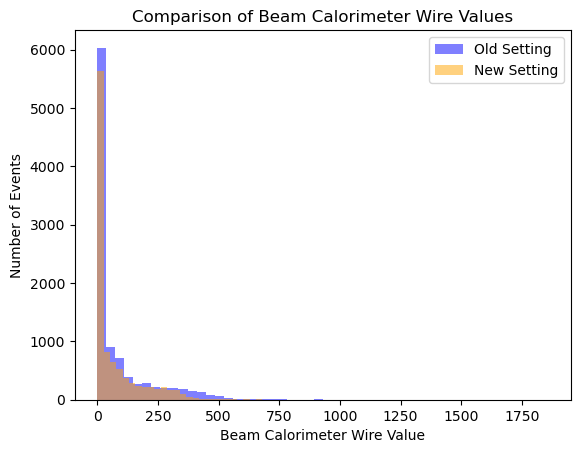

In [ ]:
plt.hist(ak.num(calo_wire_old), bins=50, alpha=0.5, label='Old Setting', color='blue')
plt.hist(ak.num(calo_wire_new), bins=50, alpha=0.5, label='New Setting', color='orange')
plt.xlabel('Beam Calorimeter Wire Value')
plt.ylabel('Number of Events')
plt.title('Comparison of Beam Calorimeter Wire Values')
plt.legend()    
plt.show()

In [ ]:
import uproot

#filename = "/storage/1/st15719/dune/H4_v34b_1GeV_-27.7_10M_1.root"
filename = "/storage/2/gj23442/H4_v34b_1GeV_-27.7_006685_412474_1_20250613T180853.root"
tree = uproot.open(filename)

generator_info = tree['NTuples;1']['GoodParticle;1']
generator_prop = generator_info.keys()

In [10]:
trackid_prop_list = list(filter(lambda x: x and x[-7:]=='TrackID', generator_prop))
trackid_prop_list

['AfterTarget_TrackID',
 'TOF1_TrackID',
 'COLL1_TrackID',
 'BPROF1_TrackID',
 'BPROF2_TrackID',
 'BPROF3_TrackID',
 'TRIG1_TrackID',
 'BPROFEXT_TrackID',
 'BPROF4_TrackID',
 'TRIG2_TrackID',
 'NP04front_TrackID',
 'NP04FieldCage_TrackID']

In [ ]:
trackid_prop_list = list(filter(lambda x: x and x[-7:]=='TrackID', generator_prop))
unique_ids, counts_trackid = [], []

for prop in trackid_prop_list:
    data = np.array(generator_info[prop].array())
    ids, count = np.unique(data, return_counts=True)
    unique_ids.append(np.array(ids, dtype=int))
    counts_trackid.append(np.array(count, dtype=int))

unique_ids = ak.Array(unique_ids)
counts_trackid = ak.Array(counts_trackid)

[ 500. 1500. 2500. 3500. 4500. 5500.]


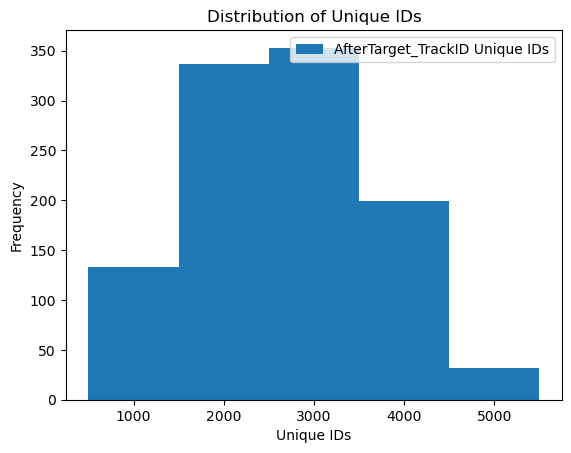

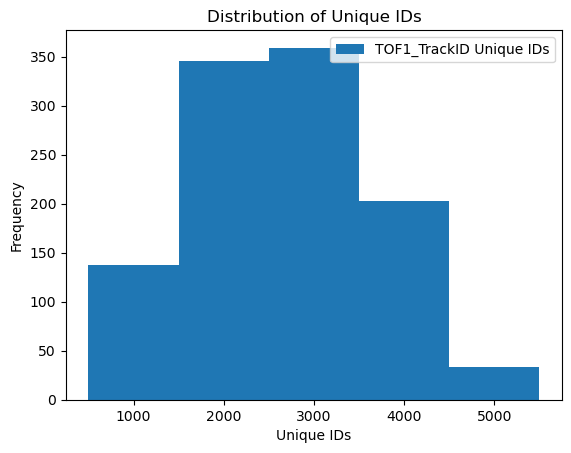

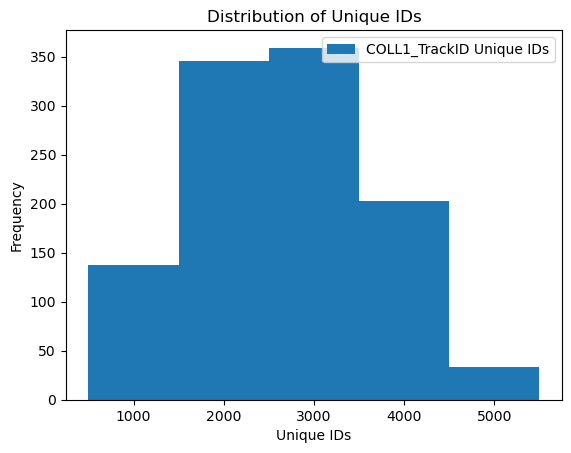

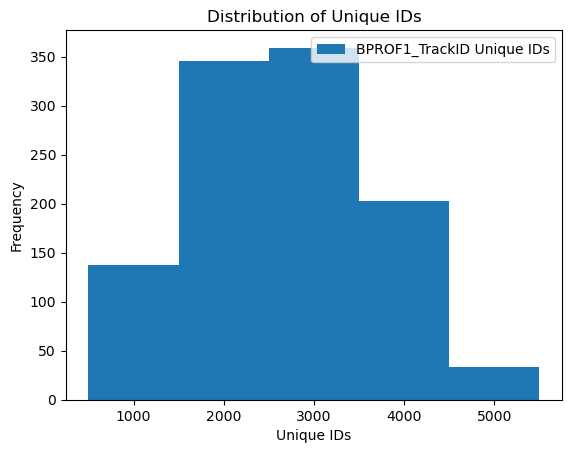

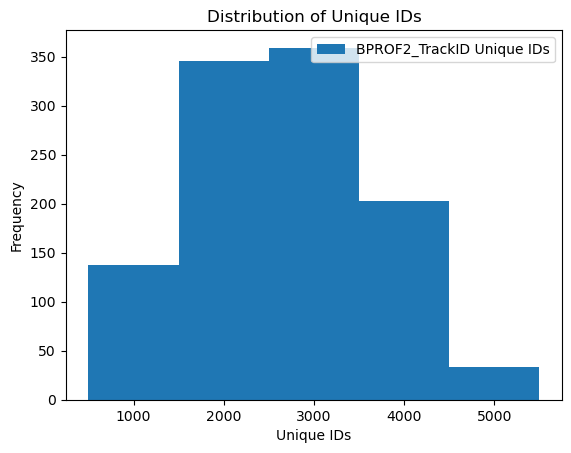

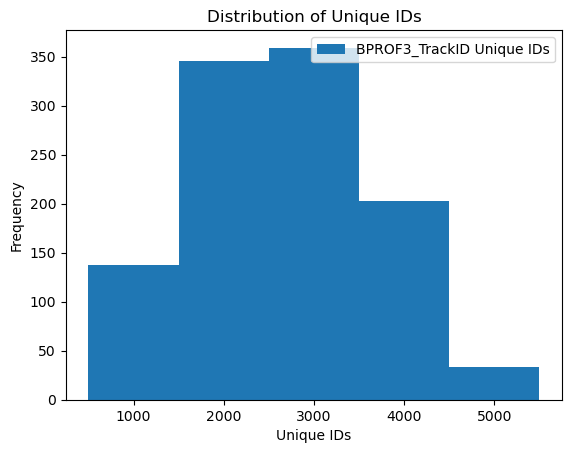

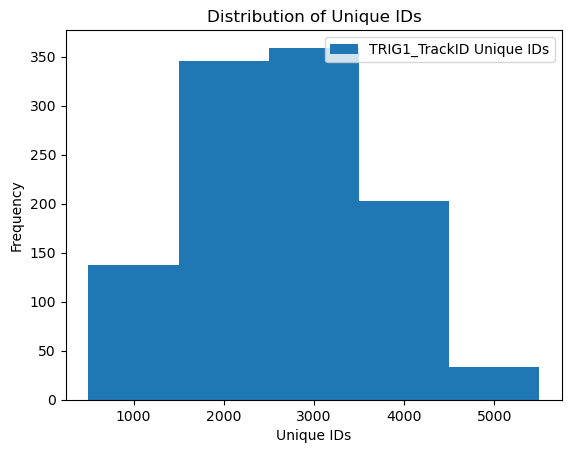

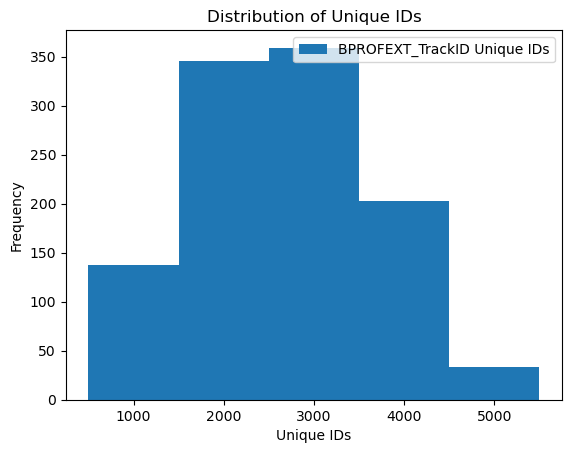

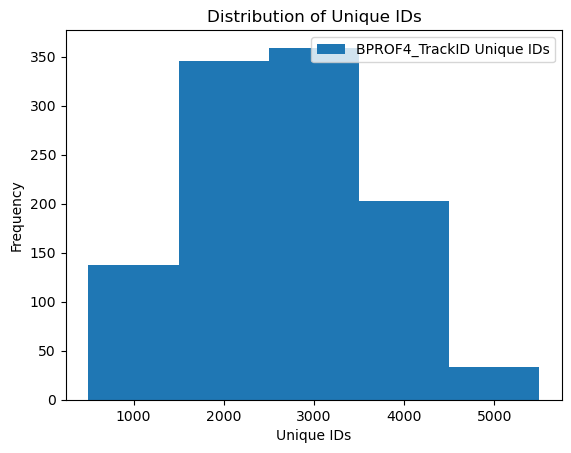

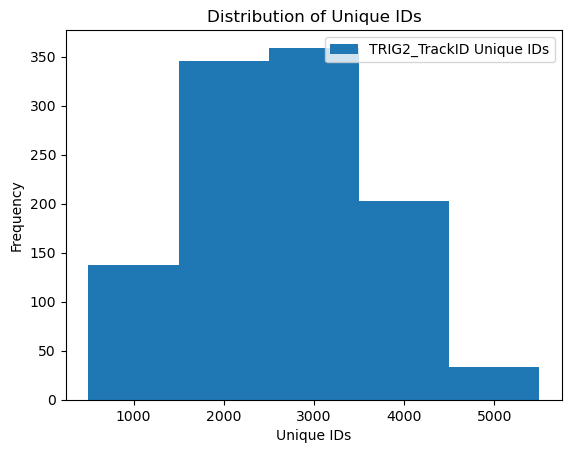

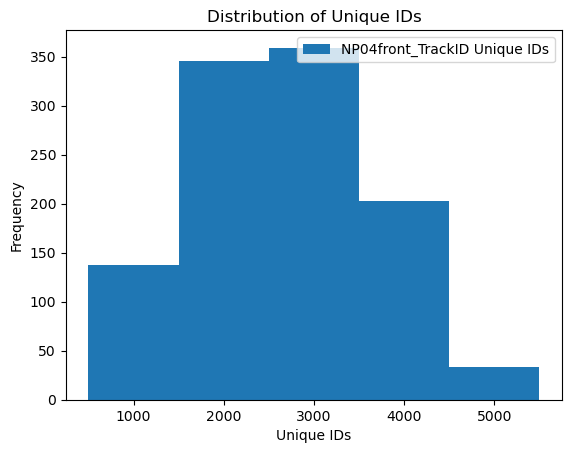

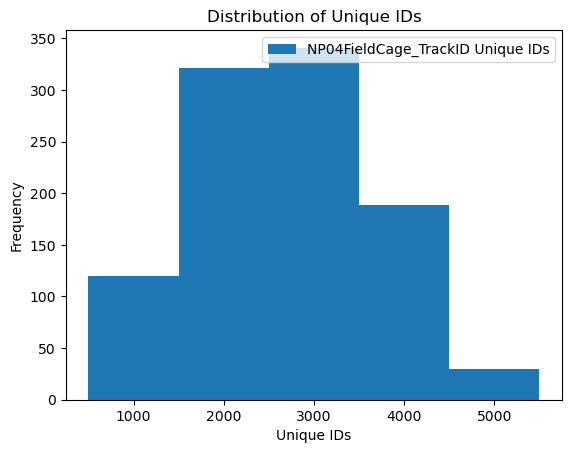

In [31]:
bin_edges=np.arange(0, 7000, 1000)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
print(bin_centers)

for i in range(len(unique_ids)):
    plt.hist(unique_ids[i], bins=bin_centers, label=f"{trackid_prop_list[i]} Unique IDs")
    plt.xlabel("Unique IDs")
    plt.ylabel("Frequency")
    plt.title("Distribution of Unique IDs")
    plt.legend()
    plt.show()

In [ ]:
unique_ids[0], unique_ids[1]

(<Array [0, 1001, 1005, ... 5378, 5518, 5810] type='1057 * int64'>,
 <Array [1001, 1005, 1009, ... 5378, 5518, 5810] type='1079 * int64'>)

In [64]:
pdgid_prop_list = list(filter(lambda x: x and x[-5:]=='PDGid', generator_prop))
unique_pdgids, counts_pdgid = [], []
for prop in pdgid_prop_list:
    data = np.array(generator_info[prop].array())
    ids, count = np.unique(data, return_counts=True)
    unique_pdgids.append(ids)
    counts_pdgid.append(count)

unique_pdgids = ak.Array(unique_pdgids)
counts_pdgid = ak.Array(counts_pdgid)

In [61]:
for i in range(len(counts_trackid)):
    print(np.unique(counts_trackid[i], return_counts=True))

(array([ 1,  2,  3,  4,  5, 29]), array([853, 172,  28,   1,   2,   1]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([1, 2, 3, 4, 5]), array([870, 178,  28,   1,   2]))
(array([  1,   2,   3,   5, 106]), array([816, 163,  22,   2,   1]))


In [67]:
for i in range(len(unique_pdgids)):
    print(np.unique(unique_pdgids[i], return_counts=True))

(array([ -13.,  -11.,    0.,  211.,  321., 2212.]), array([1, 1, 1, 1, 1, 1]))
(array([-1.30000000e+01, -1.10000000e+01,  2.11000000e+02,  3.21000000e+02,
        2.21200000e+03,  1.00001005e+09]), array([1, 1, 1, 1, 1, 1]))
(array([-1.30000000e+01, -1.10000000e+01,  2.11000000e+02,  3.21000000e+02,
        2.21200000e+03,  1.00001005e+09]), array([1, 1, 1, 1, 1, 1]))
(array([-1.30000000e+01, -1.10000000e+01,  2.11000000e+02,  3.21000000e+02,
        2.21200000e+03,  1.00001005e+09]), array([1, 1, 1, 1, 1, 1]))
(array([-1.30000000e+01, -1.10000000e+01,  2.11000000e+02,  3.21000000e+02,
        2.21200000e+03,  1.00001005e+09]), array([1, 1, 1, 1, 1, 1]))
(array([-1.30000000e+01, -1.10000000e+01,  2.11000000e+02,  3.21000000e+02,
        2.21200000e+03,  1.00001005e+09]), array([1, 1, 1, 1, 1, 1]))
(array([-1.30000000e+01, -1.10000000e+01,  2.11000000e+02,  3.21000000e+02,
        2.21200000e+03,  1.00001005e+09]), array([1, 1, 1, 1, 1, 1]))
(array([-1.30000000e+01, -1.10000000e+01,  2.

In [66]:
for i in range(len(counts_pdgid)):
    print(np.unique(counts_pdgid[i], return_counts=True))

(array([  1,   4,  29, 252, 288, 750]), array([1, 1, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 255, 293, 753]), array([2, 1, 1, 1, 1]))
(array([  1,  21, 106, 232, 234, 730]), array([1, 1, 1, 1, 1, 1]))


In [48]:
counts = ak.Array(counts)
counts

<Array [[29, 1, 1, 1, 1, 2, ... 1, 1, 1, 1, 1]] type='12 * var * int64'>

In [55]:
ak.run_lengths(counts)

<Array [[1, 4, 1, 3, 1, 4, ... 2, 1, 1, 1, 33]] type='12 * var * int64'>

In [21]:
trackid_prop_list

['AfterTarget_TrackID',
 'TOF1_TrackID',
 'COLL1_TrackID',
 'BPROF1_TrackID',
 'BPROF2_TrackID',
 'BPROF3_TrackID',
 'TRIG1_TrackID',
 'BPROFEXT_TrackID',
 'BPROF4_TrackID',
 'TRIG2_TrackID',
 'NP04front_TrackID',
 'NP04FieldCage_TrackID']

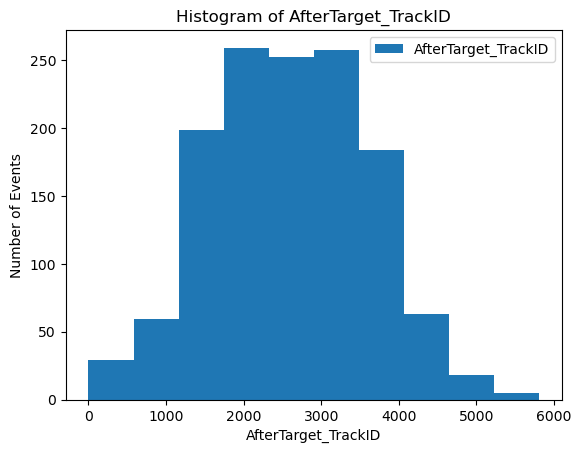

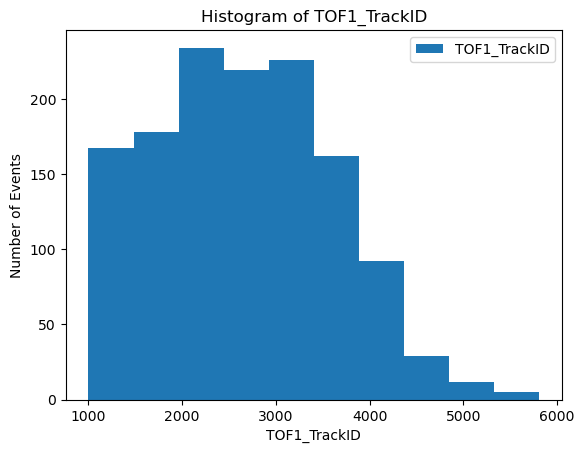

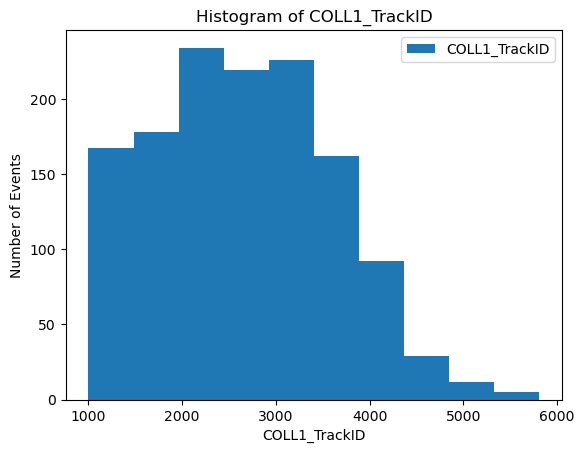

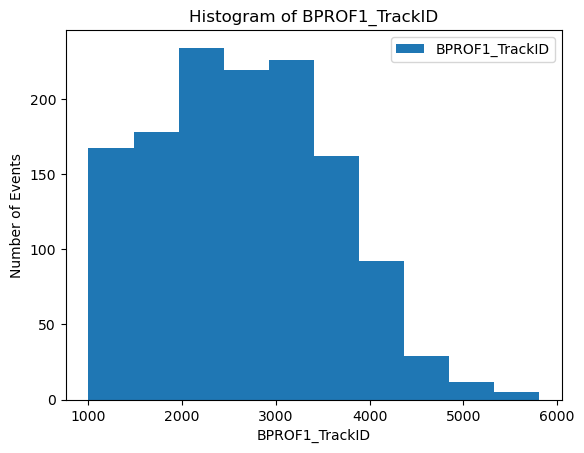

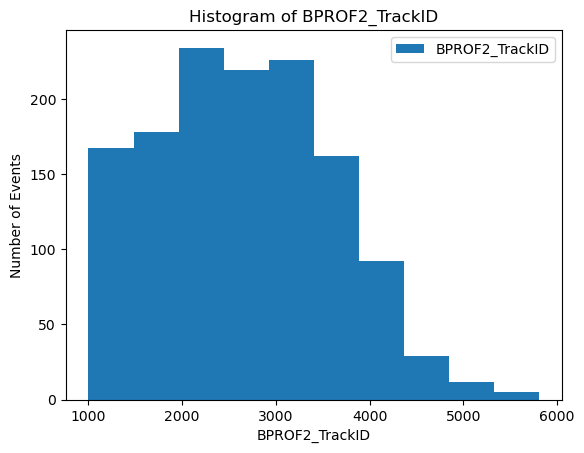

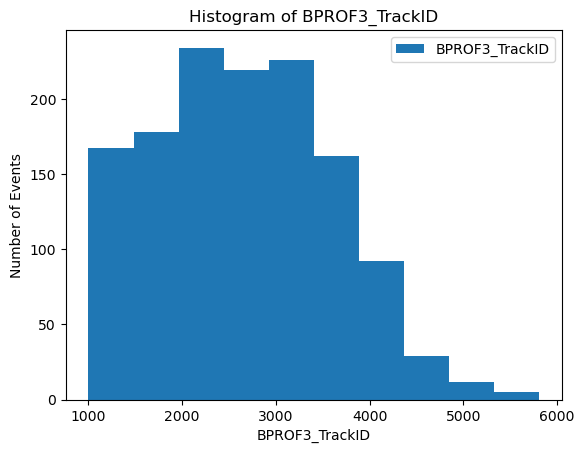

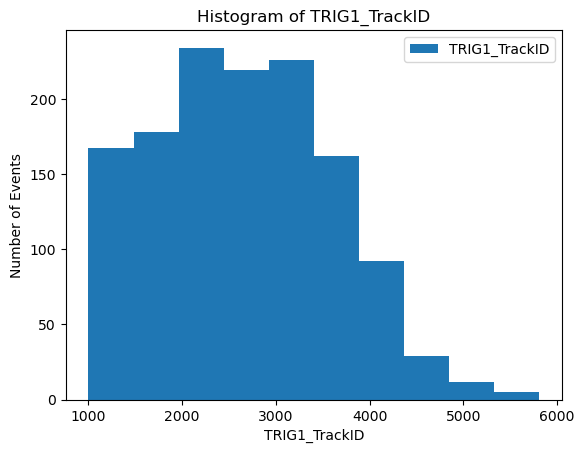

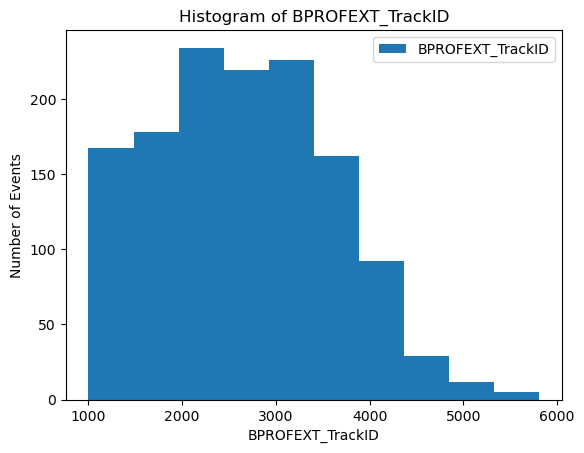

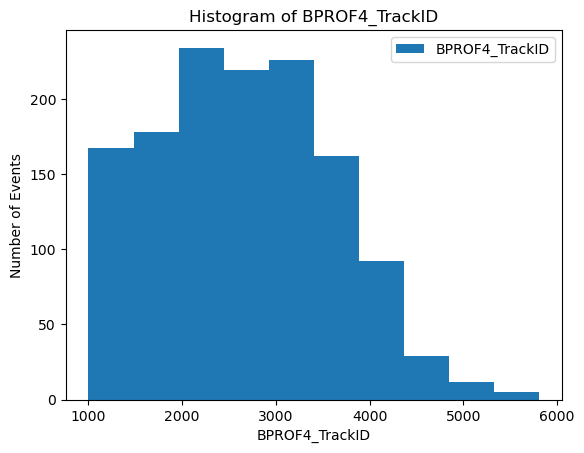

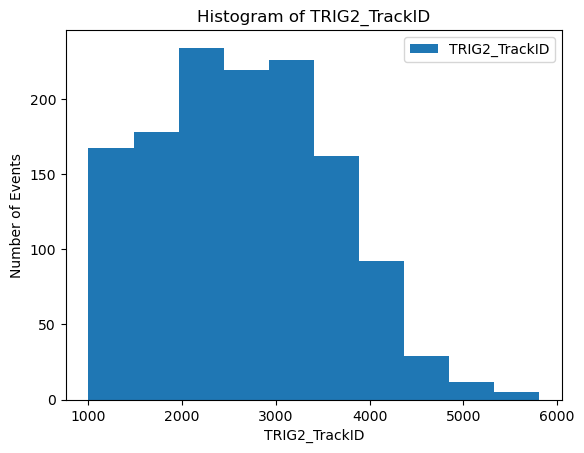

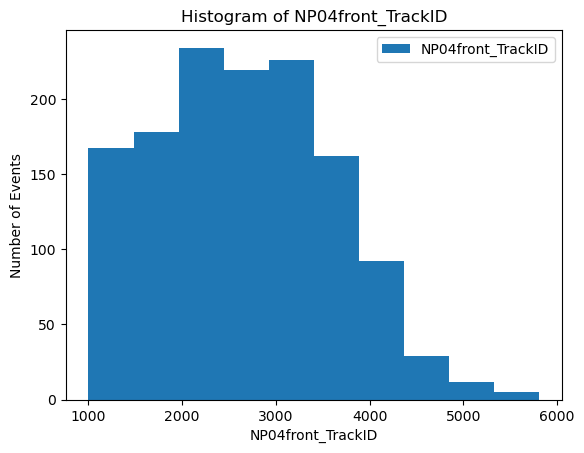

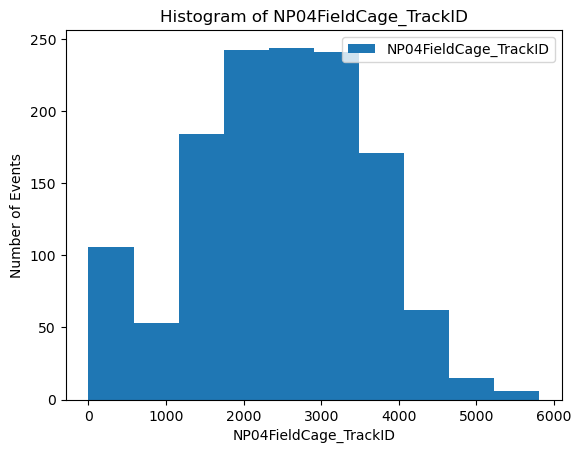

In [22]:
trackid_prop_list = list(filter(lambda x: x and x[-7:]=='TrackID', generator_prop))
for prop in trackid_prop_list:
    plt.hist(np.array(generator_info[prop].array()), bins=10, label=prop)
    plt.xlabel(prop)
    plt.ylabel('Number of Events')
    plt.title(f'Histogram of {prop}')
    plt.legend()
    plt.show()

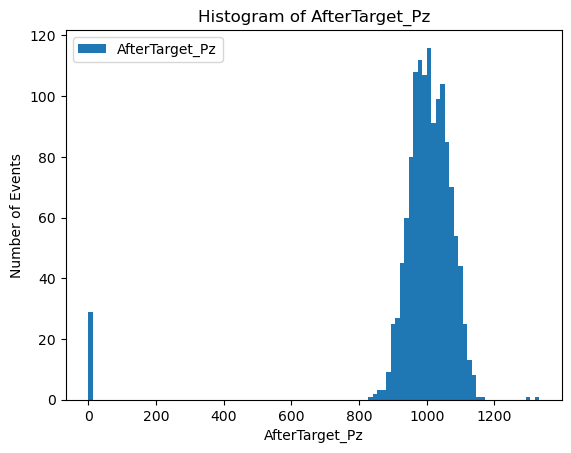

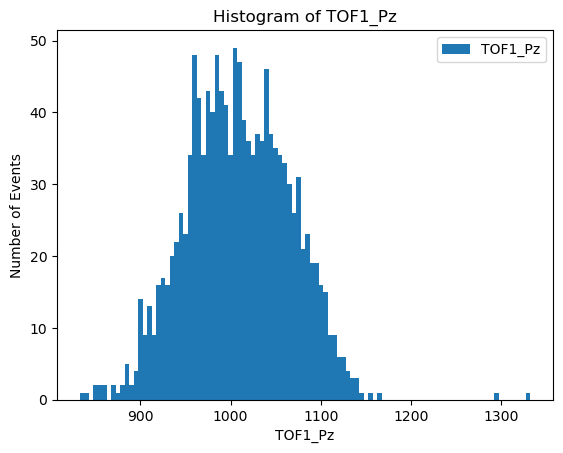

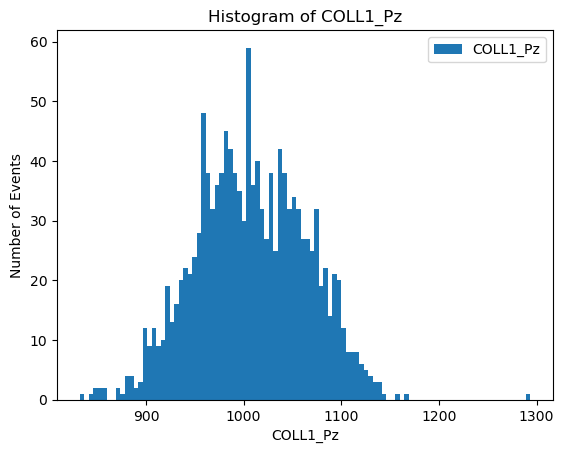

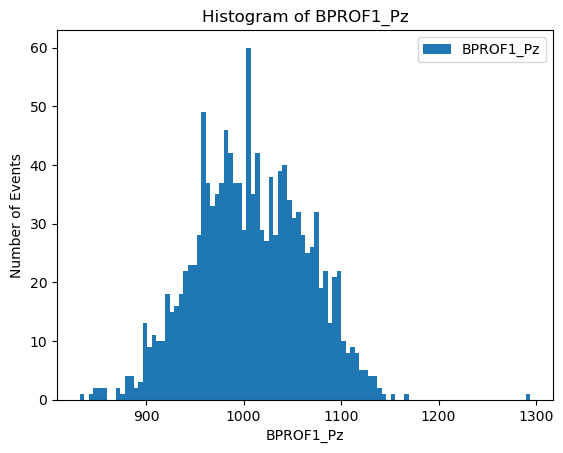

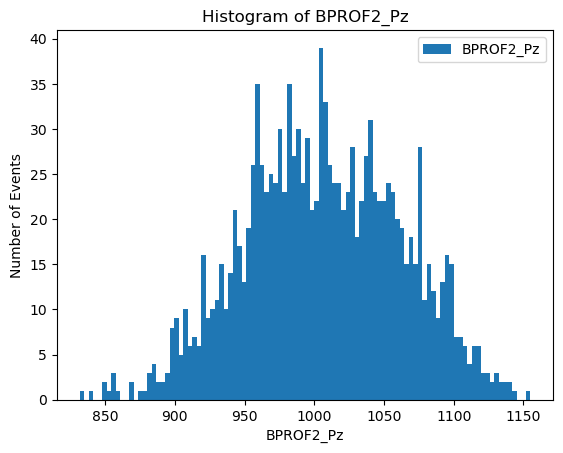

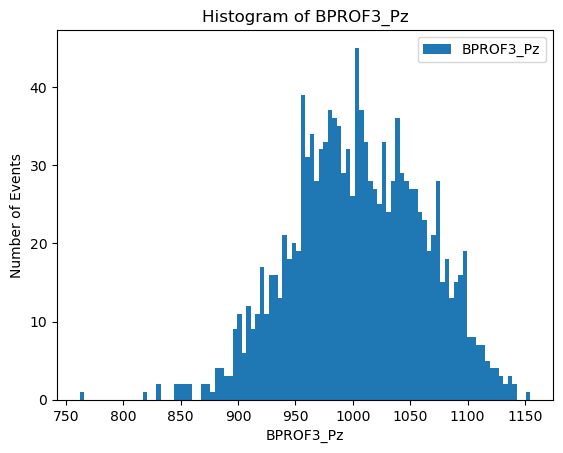

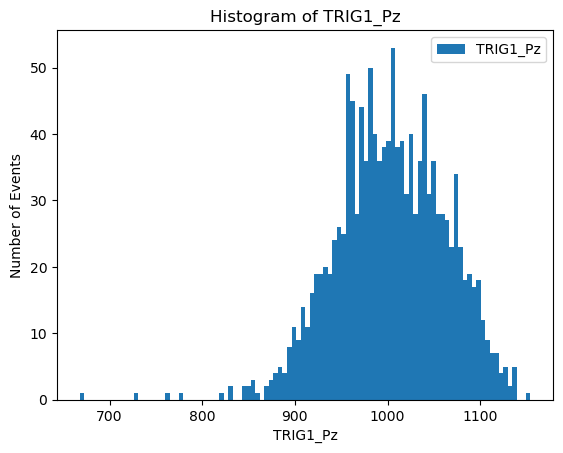

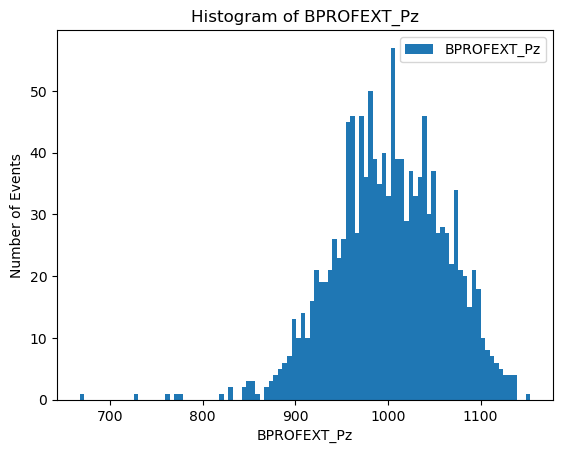

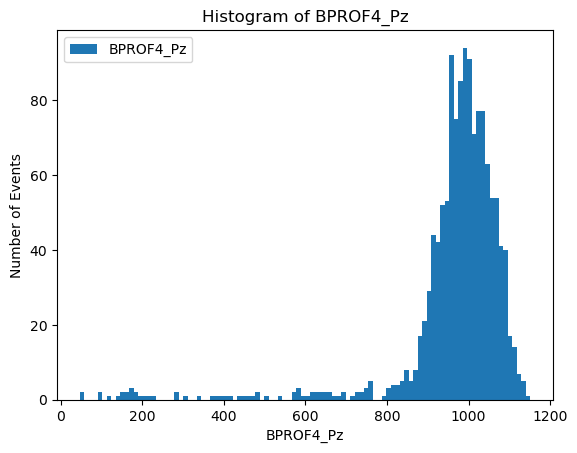

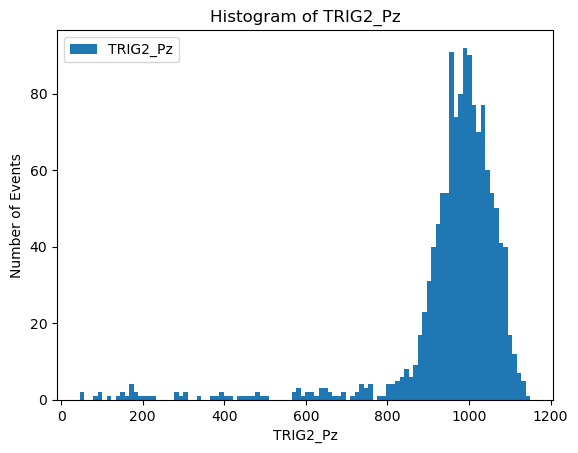

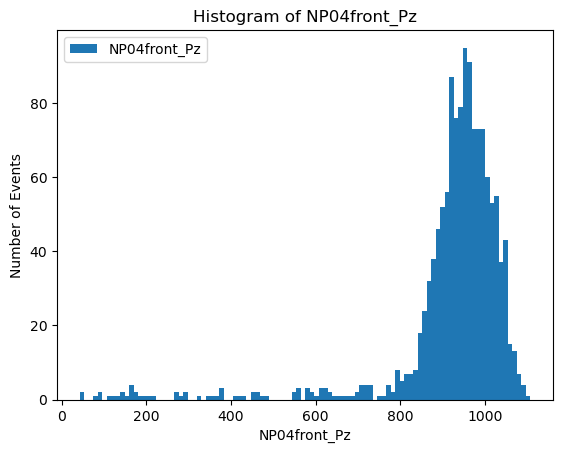

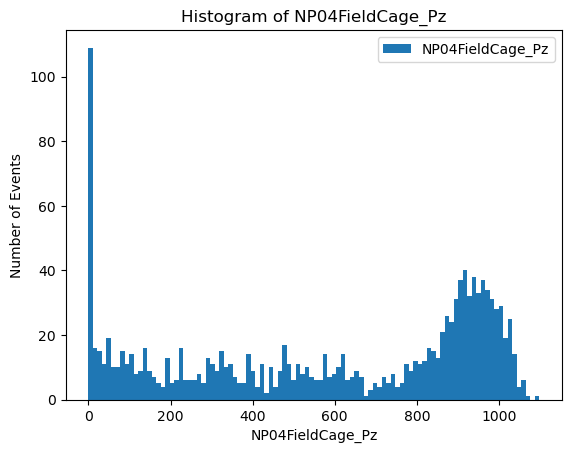

In [7]:
pz_prop_list = list(filter(lambda x: x and x[-2:]=='Pz', generator_prop))
for prop in pz_prop_list:
    plt.hist(np.array(generator_info[prop].array()), bins=100, label=prop)
    plt.xlabel(prop)
    plt.ylabel('Number of Events')
    plt.title(f'Histogram of {prop}')
    plt.legend()
    plt.show()

In [8]:
# z_prop_list = list(filter(lambda x: x and x[-2:]=='_z', generator_prop))
# for prop in z_prop_list:
#     array = np.array(generator_info[prop].array())
#     print(np.unique(array, return_counts=True))

# z_prop_list = list(filter(lambda x: x and x[-2:]=='_z', generator_prop))
# for prop in z_prop_list:
#     array = np.array(generator_info[prop].array())
#     plt.hist(array, label=prop)
#     plt.xlabel(prop)
#     plt.ylabel('Number of Events')
#     plt.title(f'Histogram of {prop}')
#     plt.legend()
#     plt.show()

In [9]:
from python.analysis import vector

pz_prop_list = list(filter(lambda x: x and x[-2:]=='Pz', generator_prop))
py_prop_list = list(filter(lambda x: x and x[-2:]=='Py', generator_prop))
px_prop_list = list(filter(lambda x: x and x[-2:]=='Px', generator_prop))

p_magnitude = []

for prop_x, prop_y, prop_z in zip(px_prop_list, py_prop_list, pz_prop_list):
    p_vector = vector.vector(generator_info[prop_x].array(), generator_info[prop_y].array(), generator_info[prop_z].array())
    p_magnitude.append(vector.magnitude(p_vector))

p_magnitude = ak.Array(p_magnitude)

In [10]:
pdg_prop_list = list(filter(lambda x: x and x[-5:]=='PDGid', generator_prop))
pdg_values = ak.Array([generator_info[prop].array() for prop in pdg_prop_list])

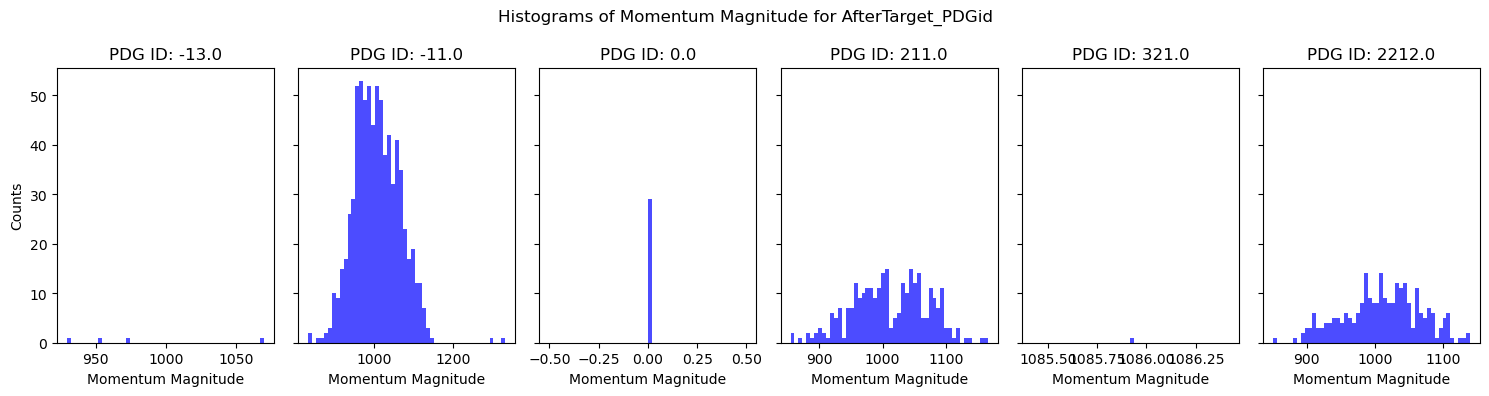

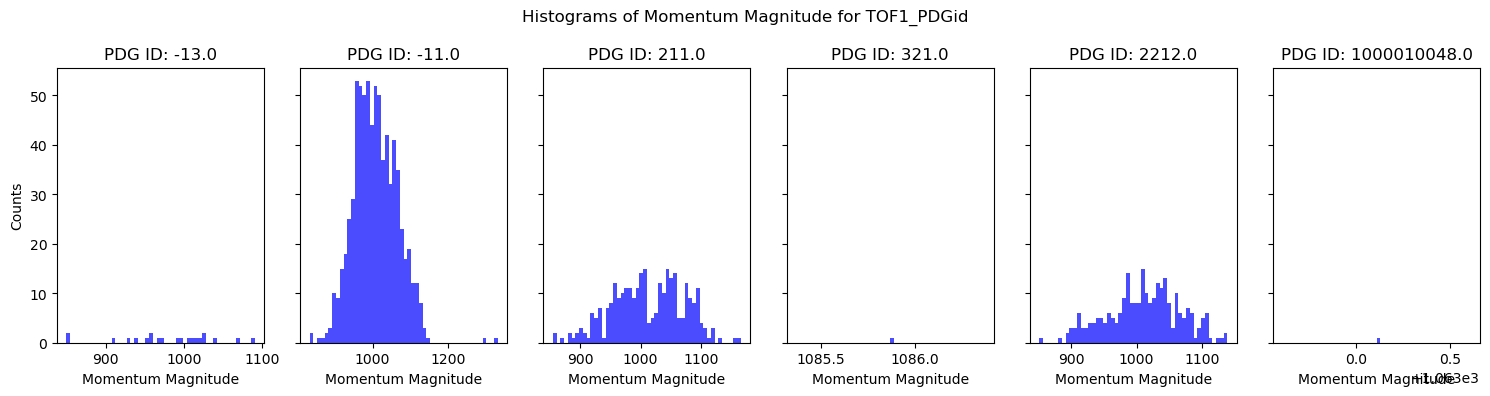

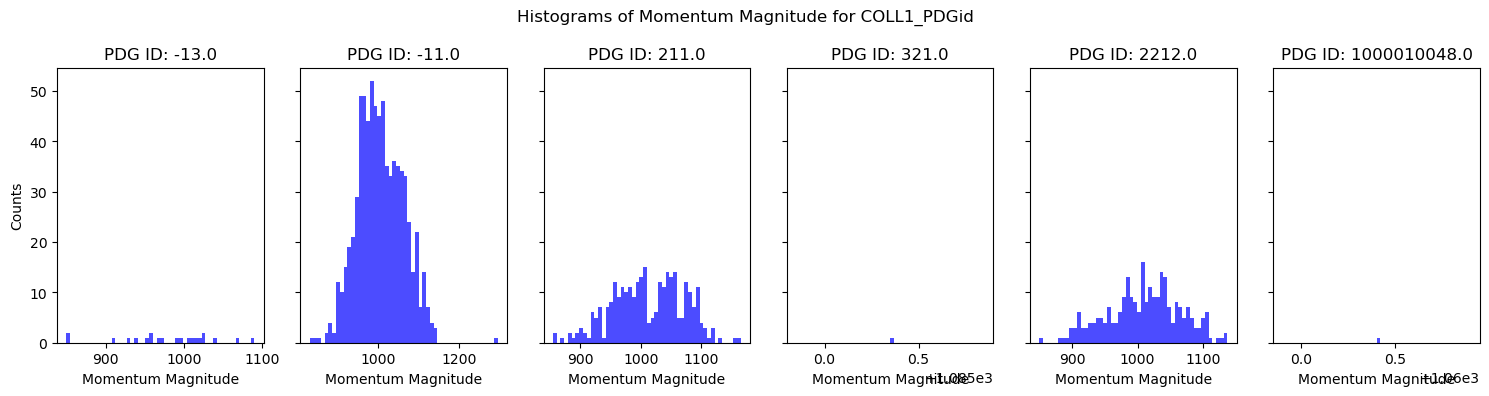

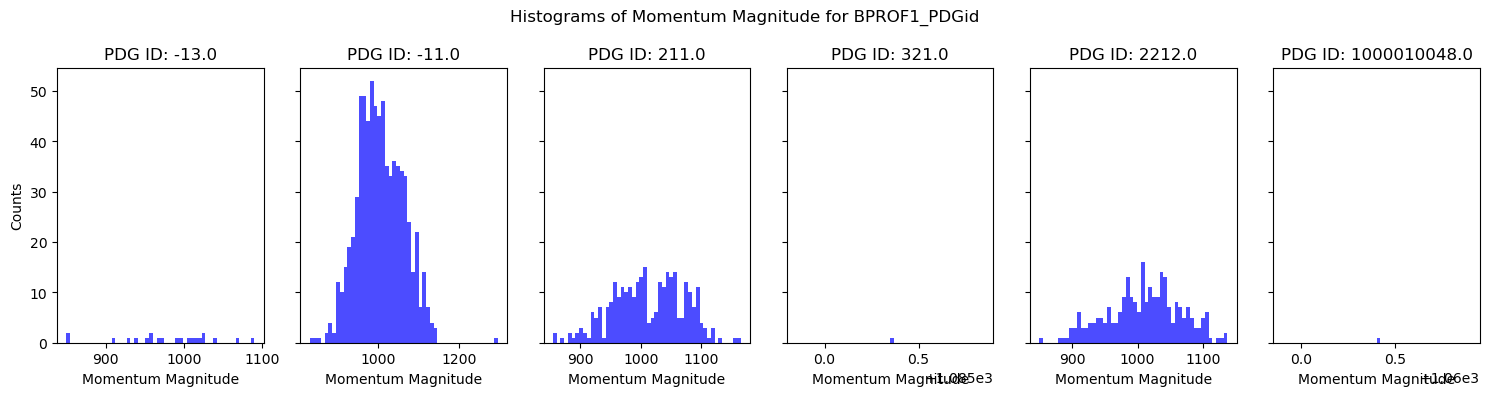

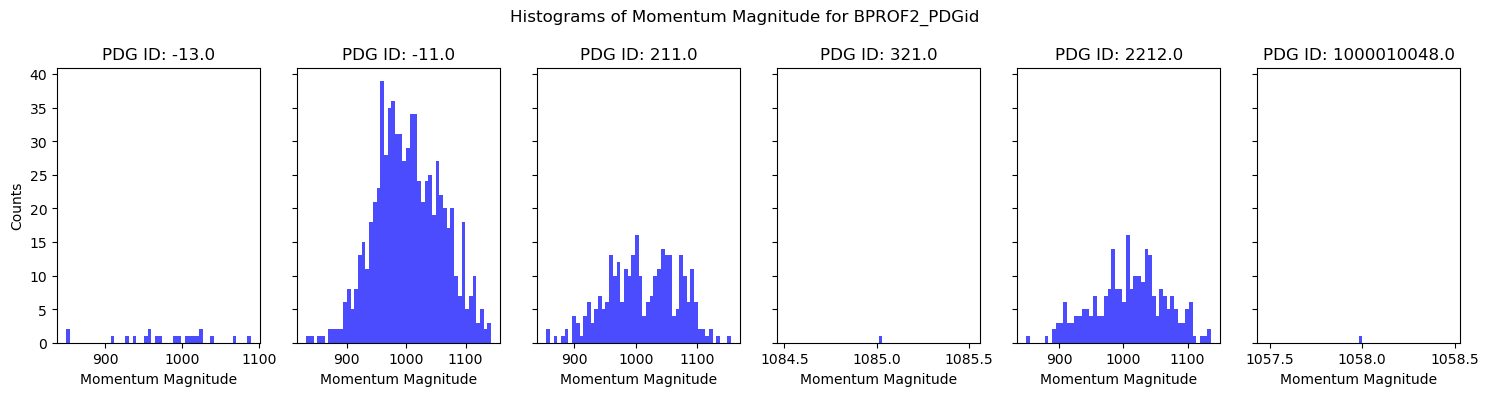

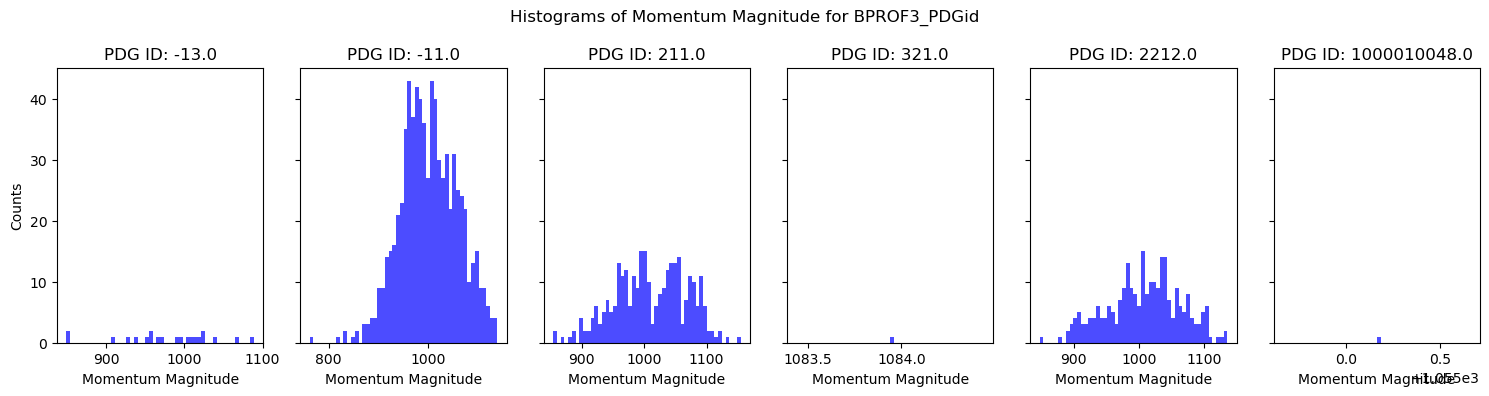

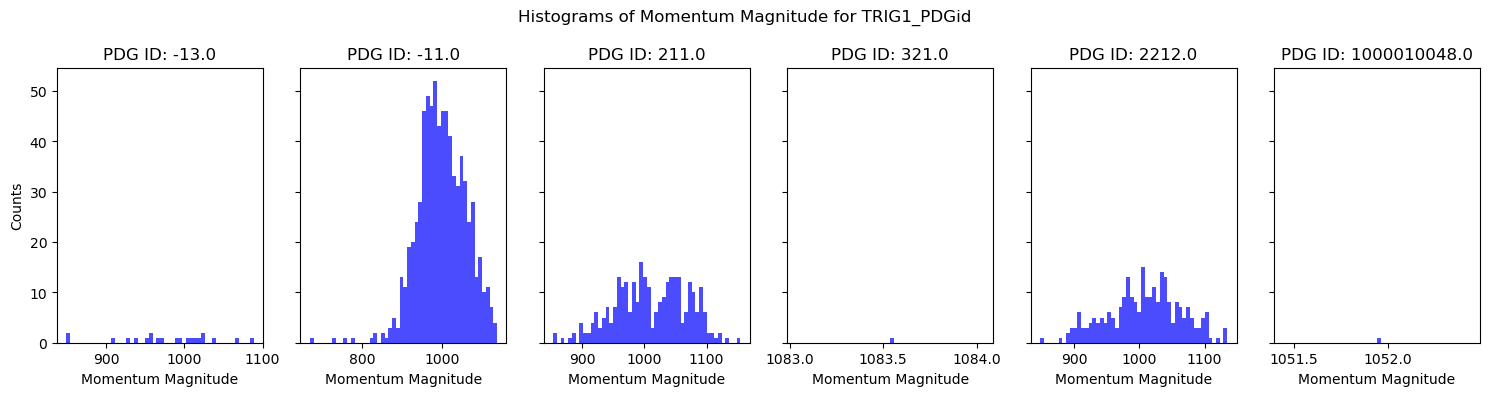

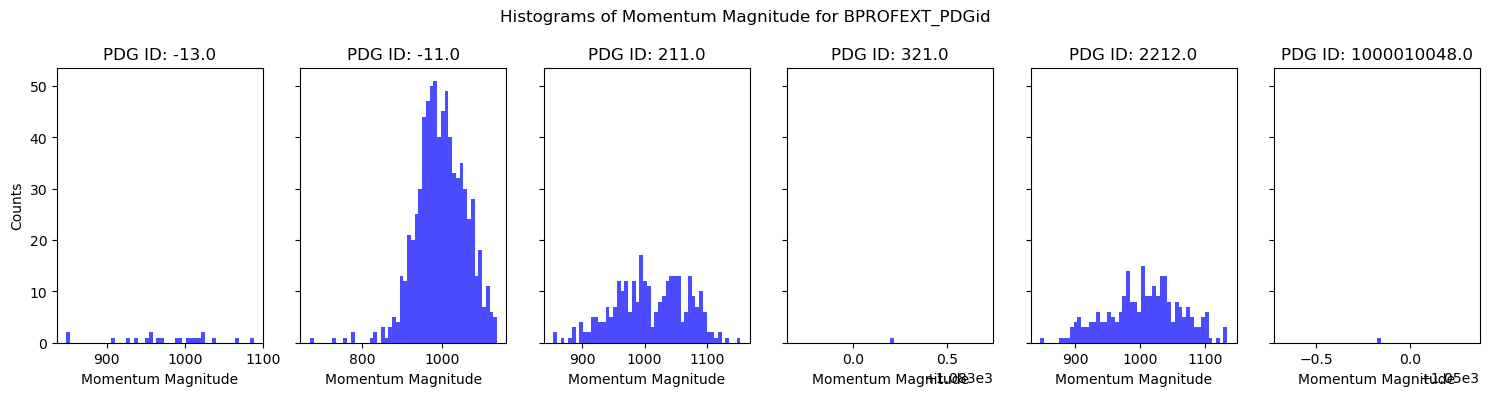

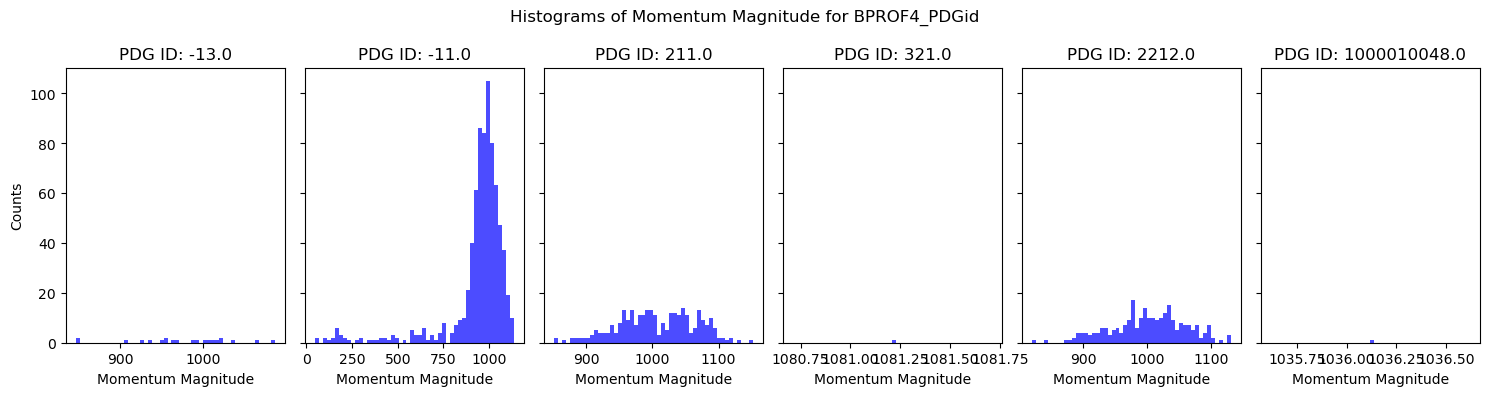

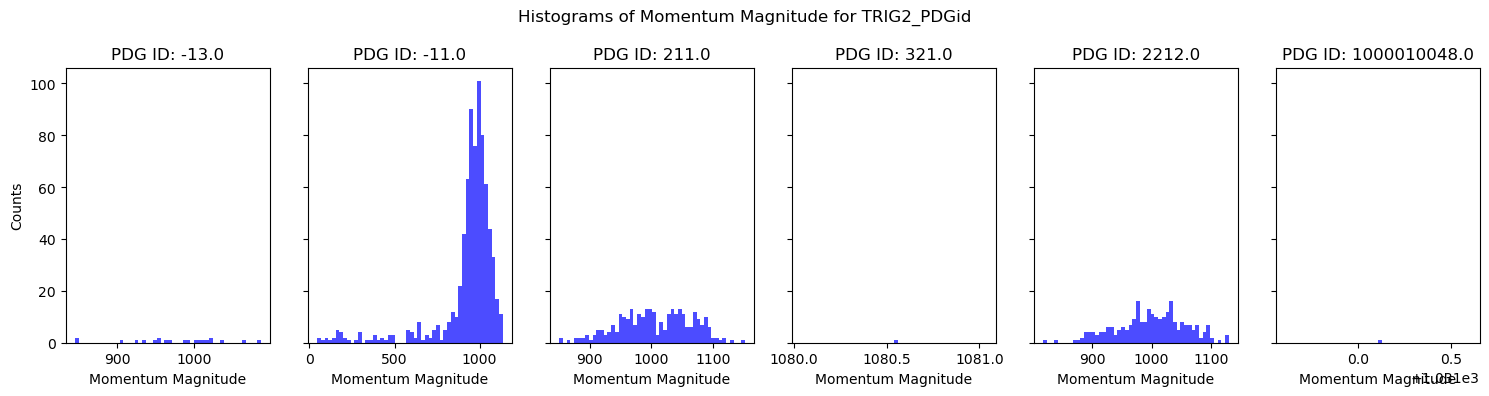

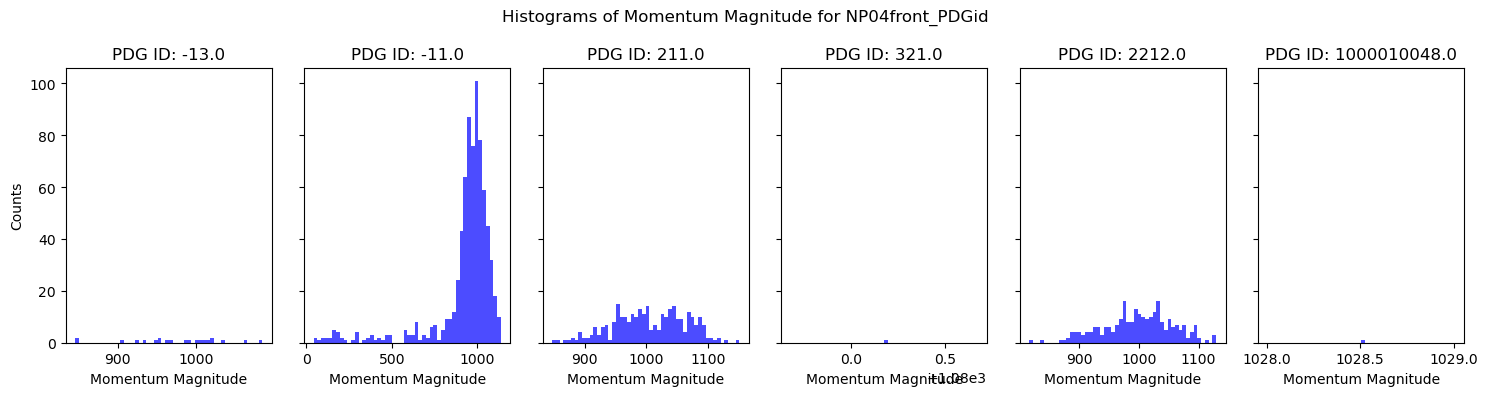

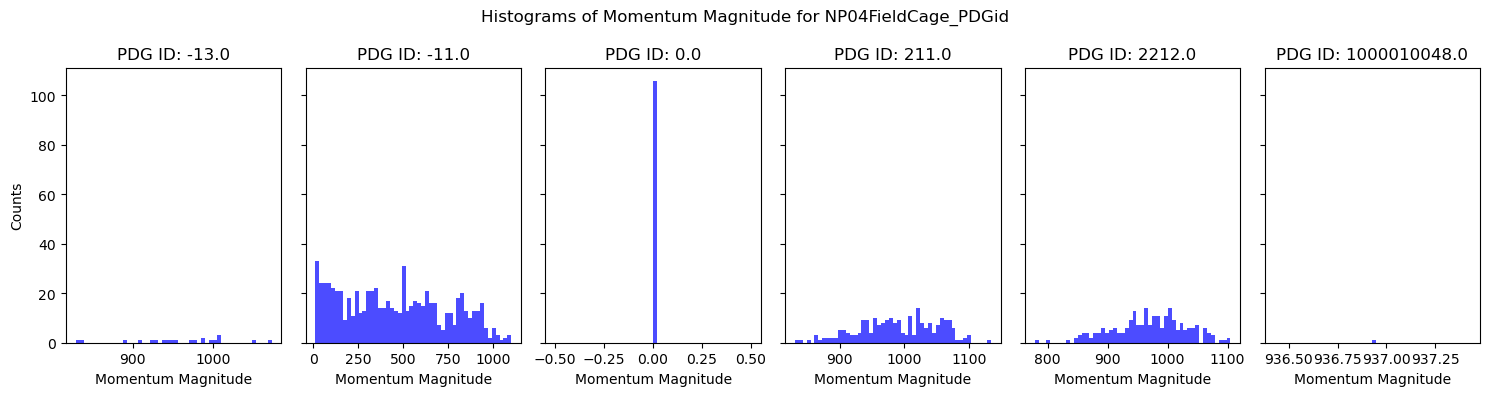

In [11]:
for i in range(len(pdg_values)):
    pdgs = np.unique(pdg_values[i])
    fig, ax = plt.subplots(1, len(pdgs), figsize=(15, 4), sharey=True)
    for j, pdg in enumerate(pdgs):
        mask_pdg = pdg_values[i] == pdg
        ax[j].hist(np.array(p_magnitude[i][mask_pdg]), bins=50, color='blue', alpha=0.7)
        ax[j].set_title(f'PDG ID: {pdg}')
        ax[j].set_xlabel('Momentum Magnitude')
        if j == 0:
            ax[j].set_ylabel('Counts')
    plt.suptitle(f'Histograms of Momentum Magnitude for {pdg_prop_list[i]}')
    plt.tight_layout()
    
